INTEGRANTES:

-Sergio Ramon
-Diego penagos
-Camilo Chavarro

# Taller: Representaciones de Texto - Word Embeddings y Embedding Contextual
## Curso de Inteligencia Artificial
---

En este taller explorarás de forma práctica cómo los embeddings transforman palabras en vectores numéricos que capturan relaciones semánticas y sintácticas.

**OBJETIVO**:

- Completa cada sección escribiendo el código Python necesario para lograr los objetivos especificados.
- Usa las instrucciones y pistas en cada celda para guiarte en la solución.


## 1. Instalación de Dependencias

Primero, instalaremos las librerías necesarias:

In [9]:
# TODO: Instalar las siguientes librerías
# - gensim
# - nltk
# - scikit-learn
# - matplotlib
# - numpy
#
# INSTRUCCIONES:
# 1. Importa subprocess y sys
# 2. Crea una lista llamada 'librerías' con las librerías mencionadas
# 3. Usa un loop para instalar cada una con pip install
# 4. Imprime un mensaje de confirmación al final

# Escribe tu código aquí

import subprocess
import sys

# Importamos los módulos necesarios
# subprocess permite ejecutar comandos del sistema (como pip install)
# sys nos ayuda a usar el mismo intérprete de Python que está corriendo el notebook
import subprocess
import sys

# Creamos la lista de librerías que necesitamos instalar
librerias = [
    "gensim",
    "nltk",
    "scikit-learn",
    "matplotlib",
    "numpy"
]

# Recorremos cada librería en la lista
for libreria in librerias:
    print(f"Instalando {libreria}...")

    # Ejecutamos el comando: python -m pip install <libreria>
    # sys.executable asegura que usamos el Python correcto del entorno actual
    subprocess.check_call([sys.executable, "-m", "pip", "install", libreria])

# Mensaje final de confirmación
print(" Todas las librerías han sido instaladas correctamente")


Instalando gensim...
Instalando nltk...
Instalando scikit-learn...
Instalando matplotlib...
Instalando numpy...
✅ Todas las librerías han sido instaladas correctamente


## 2. Conceptos Fundamentales

In [8]:
# TODO: Comparar One-Hot Encoding vs Dense Embeddings
#
# INSTRUCCIONES:
# 1. Define un vocabulario: ['inteligencia', 'artificial', 'máquina', 'aprendizaje', 'datos']
# 2. Crea un vector One-Hot para la primera palabra (todos ceros excepto el índice 0)
# 3. Crea un embedding denso usando números aleatorios (np.random.randn)
# 4. Imprime ambos vectores con sus características
#
# PISTAS:
# - Usa np.zeros() para crear el vector one-hot
# - Usa np.random.seed(42) para reproducibilidad
# - Usa np.random.randn() para crear embeddings densos

import numpy as np

# Escribe tu código aquí

# Importamos numpy para trabajar con vectores
import numpy as np

# 1. Definimos el vocabulario
vocabulario = ['inteligencia', 'artificial', 'máquina', 'aprendizaje', 'datos']

# 2. Creamos el vector One-Hot para la primera palabra
# Inicializamos un vector de ceros del tamaño del vocabulario
one_hot = np.zeros(len(vocabulario))

# Colocamos un 1 en la posición de la primera palabra (índice 0)
one_hot[0] = 1

# 3. Creamos un embedding denso
# Fijamos la semilla para que siempre genere los mismos números (reproducibilidad)
np.random.seed(42)

# Generamos un vector denso con valores aleatorios (por ejemplo tamaño 5)
embedding_denso = np.random.randn(5)

# 4. Imprimimos los resultados con sus características

print(" Vocabulario:", vocabulario)

print("\n Vector One-Hot:")
print(one_hot)
print("Características:")
print("- Dimensión:", one_hot.shape)
print("- Tipo:", type(one_hot))
print("- Solo tiene un 1 y el resto 0 (representación dispersa)")

print("\n Embedding Denso:")
print(embedding_denso)
print("Características:")
print("- Dimensión:", embedding_denso.shape)
print("- Tipo:", type(embedding_denso))
print("- Valores reales (representación continua y densa)")


📌 Vocabulario: ['inteligencia', 'artificial', 'máquina', 'aprendizaje', 'datos']

🔹 Vector One-Hot:
[1. 0. 0. 0. 0.]
Características:
- Dimensión: (5,)
- Tipo: <class 'numpy.ndarray'>
- Solo tiene un 1 y el resto 0 (representación dispersa)

🔹 Embedding Denso:
[ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]
Características:
- Dimensión: (5,)
- Tipo: <class 'numpy.ndarray'>
- Valores reales (representación continua y densa)


## 3. Word2Vec - Entrenamiento Práctico

In [7]:
# TODO: Entrenar un modelo Word2Vec
#
# INSTRUCCIONES:
# 1. Importa Word2Vec de gensim
# 2. Importa funciones de nltk para tokenizar
# 3. Define un corpus de ejemplo sobre IA/ML (al menos 5 oraciones)
# 4. Tokeniiza el corpus en oraciones y palabras
# 5. Entrena Word2Vec con los parámetros:
#    - vector_size=50
#    - window=5
#    - min_count=1
#    - sg=1 (Skip-gram)
# 6. Imprime información del modelo entrenado
#
# PISTAS:
# - Usa sent_tokenize para separar oraciones
# - Usa word_tokenize para separar palabras
# - Descarga los recursos necesarios de nltk con nltk.download()

from gensim.models import Word2Vec
from nltk.tokenize import sent_tokenize, word_tokenize
import nltk

# Descarga los recursos necesarios
# nltk.download('punkt')

# Corpus sobre inteligencia artificial (puedes modificarlo)
corpus = '''
[Escribe aquí al menos 5 oraciones sobre aprendizaje automático, redes neuronales o embeddings]
'''

# Escribe tu código aquí

from gensim.models import Word2Vec
from nltk.tokenize import sent_tokenize, word_tokenize
import nltk

nltk.download('punkt')

try:
    nltk.download('punkt_tab')
except:
    pass

corpus = '''
La inteligencia artificial permite que las máquinas aprendan de los datos.
El aprendizaje automático es una rama de la inteligencia artificial.
Las redes neuronales se inspiran en el funcionamiento del cerebro humano.
Los embeddings representan palabras como vectores densos en un espacio numérico.
El procesamiento de lenguaje natural utiliza modelos para comprender texto.
Los algoritmos de machine learning encuentran patrones en grandes volúmenes de datos.
'''

oraciones = sent_tokenize(corpus)
oraciones_tokenizadas = [word_tokenize(oracion.lower()) for oracion in oraciones]

modelo = Word2Vec(
    sentences=oraciones_tokenizadas,
    vector_size=50,
    window=5,
    min_count=1,
    sg=1
)

print("Tamaño del vocabulario:", len(modelo.wv.index_to_key))
print("Palabras:", modelo.wv.index_to_key)

print("\nVector de 'inteligencia':")
print(modelo.wv["inteligencia"])

print("\nSimilares a 'inteligencia':")
print(modelo.wv.most_similar("inteligencia"))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Tamaño del vocabulario: 51
Palabras: ['.', 'de', 'en', 'el', 'los', 'datos', 'las', 'artificial', 'inteligencia', 'la', 'volúmenes', 'grandes', 'patrones', 'encuentran', 'learning', 'machine', 'algoritmos', 'texto', 'comprender', 'para', 'modelos', 'utiliza', 'natural', 'lenguaje', 'procesamiento', 'numérico', 'espacio', 'un', 'densos', 'vectores', 'como', 'palabras', 'representan', 'embeddings', 'humano', 'cerebro', 'del', 'funcionamiento', 'inspiran', 'se', 'neuronales', 'redes', 'rama', 'una', 'es', 'automático', 'aprendizaje', 'aprendan', 'máquinas', 'que', 'permite']

Vector de 'inteligencia':
[-0.01426375  0.00253634 -0.01427504 -0.00444047  0.0073133   0.01160263
  0.00235091  0.00420695 -0.00830738  0.01436756 -0.01257976  0.009187
 -0.01637901  0.00415744 -0.00994752 -0.00842648 -0.00608602  0.01138804
  0.01143025 -0.01007941  0.00159987 -0.01684422  0.01572905  0.01846523
 -0.005422    0.00171631  0.00152129  0.01107605 -0.01722208  0.00119936
  0.01366932  0.00435425  0.002

## 4. Visualización con t-SNE

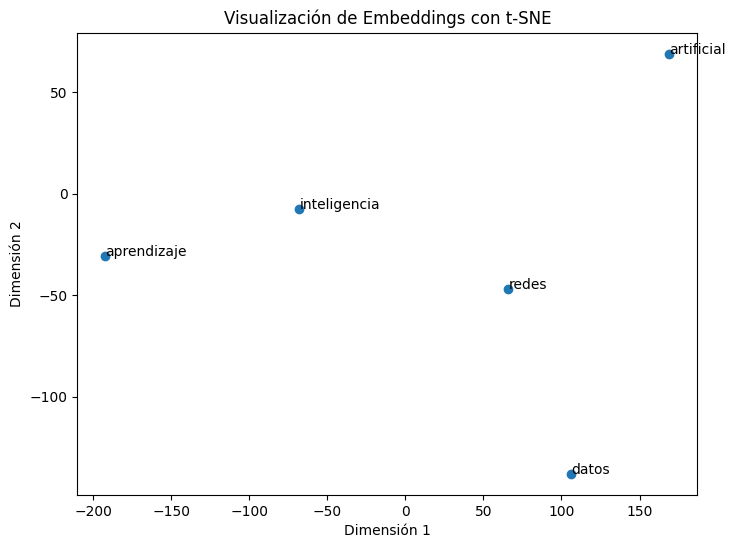

In [6]:
# TODO: Visualizar embeddings con t-SNE
#
# INSTRUCCIONES:
# 1. Selecciona 5 palabras que existan en el modelo entrenado
# 2. Obtén sus vectores del modelo
# 3. Usa t-SNE para reducir a 2 dimensiones (perplexity=2)
# 4. Crea un gráfico scatter con los puntos
# 5. Añade anotaciones con los nombres de las palabras
# 6. Añade título y etiquetas a los ejes
#
# PISTAS:
# - TSNE viene de sklearn.manifold
# - Usa plt.scatter() para graficar los puntos
# - Usa plt.annotate() para añadir etiquetas
# - Usa fit_transform() para ajustar y transformar los dados

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Selecciona palabras que existan en tu modelo
palabras = []  # Completa con palabras válidas

# Escribe tu código aquí

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Seleccionamos 5 palabras que existan en el modelo entrenado
palabras = ["inteligencia", "artificial", "aprendizaje", "datos", "redes"]

# Obtenemos los vectores de esas palabras
vectores = np.array([modelo.wv[palabra] for palabra in palabras])

# Aplicamos t-SNE para reducir los vectores a 2 dimensiones
tsne = TSNE(n_components=2, perplexity=2, random_state=42)
vectores_2d = tsne.fit_transform(vectores)

# Creamos el gráfico
plt.figure(figsize=(8, 6))
plt.scatter(vectores_2d[:, 0], vectores_2d[:, 1])

# Añadimos anotaciones con los nombres de las palabras
for i, palabra in enumerate(palabras):
    plt.annotate(palabra, (vectores_2d[i, 0], vectores_2d[i, 1]))

# Añadimos título y etiquetas
plt.title("Visualización de Embeddings con t-SNE")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")

# Mostramos el gráfico
plt.show()


## 5. Clasificación de Textos con Embeddings

In [5]:
# TODO: Clasificar textos usando embeddings
#
# INSTRUCCIONES:
# 1. Define una función que calcule el embedding promedio de un texto
#    - Tokeniza el texto
#    - Obtén vectores de palabras que existan en el modelo
#    - Retorna el promedio de esos vectores
# 2. Crea un dataset con 4 textos de ejemplo y sus etiquetas (positivo=1, negativo=0)
# 3. Obtén los embeddings promedios para cada texto
# 4. Entrena un clasificador LogisticRegression
# 5. Evalúa la precisión en los datos de entrenamiento
# 6. Haz una predicción en un nuevo texto de prueba
#
# PISTAS:
# - np.mean() para promediar vectores
# - LogisticRegression de sklearn.linear_model
# - clf.fit() para entrenar
# - clf.score() para evaluar
# - clf.predict() para predecir

from sklearn.linear_model import LogisticRegression

def get_embedding_avg(texto, modelo):
    # Escribe la función aquí
    pass

# Dataset de ejemplo (puedes crear tus propios ejemplos)
textos = []  # Completa con 4 textos
etiquetas = []  # Completa con sus etiquetas (0 o 1)

# Escribe tu código aquí
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
import numpy as np

#  Tokenizador simple (evita errores de NLTK)
def simple_tokenize(texto):
    return texto.lower().split()

# Corpus
corpus = [
    "la inteligencia artificial aprende de los datos",
    "el aprendizaje automático mejora con experiencia",
    "las redes neuronales procesan información",
    "los datos son importantes en machine learning",
    "los modelos pueden fallar si hay errores"
]

# Tokenización
oraciones_tokenizadas = [simple_tokenize(oracion) for oracion in corpus]

# Entrenamos Word2Vec
modelo = Word2Vec(
    sentences=oraciones_tokenizadas,
    vector_size=50,
    window=5,
    min_count=1,
    sg=1
)

# Función embedding promedio
def get_embedding_avg(texto, modelo):
    palabras = simple_tokenize(texto)
    vectores = [modelo.wv[p] for p in palabras if p in modelo.wv]

    if len(vectores) == 0:
        return np.zeros(modelo.vector_size)

    return np.mean(vectores, axis=0)

# Dataset
textos = [
    "me gusta el aprendizaje automático",
    "los datos son útiles",
    "odio los errores en el sistema",
    "no me gusta fallar"
]

etiquetas = [1, 1, 0, 0]

# Embeddings
X = np.array([get_embedding_avg(t, modelo) for t in textos])
y = np.array(etiquetas)

# Modelo
clf = LogisticRegression()
clf.fit(X, y)

# Evaluación
print("Precisión:", clf.score(X, y))

# Prueba
texto_prueba = "me gusta la inteligencia artificial"
pred = clf.predict([get_embedding_avg(texto_prueba, modelo)])

print("Predicción (1=positivo, 0=negativo):", pred[0])

Precisión: 0.75
Predicción (1=positivo, 0=negativo): 1


## 6. Conclusiones

En este taller hemos aprendido:
- Conceptos fundamentales de embeddings
- Entrenamiento de Word2Vec
- Visualización y análisis
- Aplicación en clasificación de textos

¡Felicidades por completar el taller!